In [2]:
pip install pandas pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
pip install matplotlib

  Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp311-cp311-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp311-cp311-win_amd64.whl.metadata (6.4 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp311-cp311-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.4.9-cp311-cp311-win_amd64.whl (73 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:

!pip install tensorflow

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import tensorflow as tf

print(tf.__version__)

2.20.0


In [39]:
import pandas as pd

df = pd.read_parquet("predictive_maintenance_log_v5_featured.parquet")

df

,PrinterID,ReferenceDate,log_alert_count_3m,log_warning_alert_count_3m,log_critical_alert_count_3m,unique_alert_codes_3m,log_alert_count_1m,log_warning_alert_count_1m,log_critical_alert_count_1m,unique_alert_codes_1m,...,critical_x_service_history,log_job_volume_3m,log_color_job_volume_3m,log_bw_job_volume_3m,log_job_volume_1m,job_growth_ratio,days_since_last_service,service_count_1yr,is_neglected,ServiceRequiredNext_30_Days
0,4da956db-a9bd-490c-8570-0a18c3fcb2f0,2025-07-01,5.463832,5.446737,1.609438,11.0,4.744932,4.736198,0.693147,6.0,...,0.0,7.594381,7.259820,6.318968,7.594381,1.0,530,0,1,0
1,0eb0bdd6-0308-4a0b-9c06-c8b1d6f5b171,2025-07-01,5.075174,5.017280,2.302585,12.0,4.025352,4.025352,0.000000,4.0,...,36.0,5.225747,4.605170,3.737670,5.225747,1.0,49,4,0,0
2,c4c7a34a-3130-4320-9eaf-7c11c0cc0f0d,2025-07-01,4.691348,4.682131,0.693147,5.0,4.204693,4.189655,0.693147,3.0,...,5.0,6.001415,0.000000,6.001415,6.001415,1.0,292,5,0,0
3,3b1c643d-0adc-4f34-972a-60d8cc7e5cbb,2025-07-01,4.430817,0.000000,3.637586,9.0,4.430817,0.000000,3.637586,9.0,...,185.0,4.624973,0.000000,4.624973,4.624973,1.0,25,5,0,1
4,5de0fc8d-3cee-4058-bf2f-47273d9766d6,2025-07-01,3.610918,2.995732,2.890372,11.0,2.995732,2.397895,2.302585,5.0,...,0.0,7.389564,5.950643,6.744059,7.389564,1.0,886,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
460667,f73929d9-e7ef-4e8c-a27c-771b606d2c58,2025-05-01,6.006353,5.961005,2.944439,13.0,5.389072,5.337538,2.484907,6.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,1134,0,1,0
460668,466548f6-1527-4ec0-9a8f-e81f0822e593,2025-05-01,6.770789,5.673323,3.610918,23.0,6.049733,4.955827,2.564949,12.0,...,180.0,0.000000,0.000000,0.000000,0.000000,0.0,59,5,0,0
460669,38cf5715-572a-462e-9182-24ad551652c0,2025-05-01,5.869297,4.672829,0.000000,9.0,4.990433,3.761200,0.000000,4.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,577,0,1,0
460670,870931c5-1d3d-489d-8969-75bfe05d2274,2025-05-01,6.126869,5.963579,4.248495,19.0,4.644391,4.499810,2.708050,8.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,395,0,1,0


In [ ]:
df.shape



(460672, 37)

In [7]:
df.columns

Index(['PrinterID', 'ReferenceDate', 'log_alert_count_3m',
       'log_warning_alert_count_3m', 'log_critical_alert_count_3m',
       'unique_alert_codes_3m', 'log_alert_count_1m',
       'log_warning_alert_count_1m', 'log_critical_alert_count_1m',
       'unique_alert_codes_1m', 'critical_ratio_3m', 'critical_ratio_1m',
       'warning_ratio_3m', 'warning_ratio_1m', 'alert_growth_ratio',
       'total_alert_intensity', 'alert_intensity_3m', 'alert_intensity_1m',
       'critical_intensity_3m', 'warning_intensity_1m', 'warning_intensity_3m',
       'critical_intensity_1m', 'alert_spike', 'warning_spike',
       'critical_spike', 'warning_to_critical_ratio_1m',
       'critical_ratio_change', 'critical_x_service_history',
       'log_job_volume_3m', 'log_color_job_volume_3m', 'log_bw_job_volume_3m',
       'log_job_volume_1m', 'job_growth_ratio', 'days_since_last_service',
       'service_count_1yr', 'is_neglected', 'ServiceRequiredNext_30_Days'],
      dtype='object')

In [35]:
df.ServiceRequiredNext_30_Days.value_counts()

ServiceRequiredNext_30_Days
0    395384
1     65288
Name: count, dtype: int64

In [21]:
df.unique_alert_codes_3m.max()

np.float64(54.0)

In [22]:
df.unique_alert_codes_3m.min()

np.float64(1.0)

In [8]:
df.dtypes

PrinterID                               object
ReferenceDate                   datetime64[us]
log_alert_count_3m                     float64
log_warning_alert_count_3m             float64
log_critical_alert_count_3m            float64
unique_alert_codes_3m                  float64
log_alert_count_1m                     float64
log_warning_alert_count_1m             float64
log_critical_alert_count_1m            float64
unique_alert_codes_1m                  float64
critical_ratio_3m                      float64
critical_ratio_1m                      float64
warning_ratio_3m                       float64
warning_ratio_1m                       float64
alert_growth_ratio                     float64
total_alert_intensity                  float64
alert_intensity_3m                     float64
alert_intensity_1m                     float64
critical_intensity_3m                  float64
warning_intensity_1m                   float64
warning_intensity_3m                   float64
critical_inte

In [9]:
df.isnull().sum()


 

PrinterID                       0
ReferenceDate                   0
log_alert_count_3m              0
log_warning_alert_count_3m      0
log_critical_alert_count_3m     0
unique_alert_codes_3m           0
log_alert_count_1m              0
log_warning_alert_count_1m      0
log_critical_alert_count_1m     0
unique_alert_codes_1m           0
critical_ratio_3m               0
critical_ratio_1m               0
warning_ratio_3m                0
warning_ratio_1m                0
alert_growth_ratio              0
total_alert_intensity           0
alert_intensity_3m              0
alert_intensity_1m              0
critical_intensity_3m           0
warning_intensity_1m            0
warning_intensity_3m            0
critical_intensity_1m           0
alert_spike                     0
warning_spike                   0
critical_spike                  0
warning_to_critical_ratio_1m    0
critical_ratio_change           0
critical_x_service_history      0
log_job_volume_3m               0
log_color_job_

In [10]:
numerical_cols=[ 'log_alert_count_3m',
       'log_warning_alert_count_3m', 'log_critical_alert_count_3m',
       'unique_alert_codes_3m', 'log_alert_count_1m',
       'log_warning_alert_count_1m', 'log_critical_alert_count_1m',
       'unique_alert_codes_1m', 'critical_ratio_3m', 'critical_ratio_1m',
       'warning_ratio_3m', 'warning_ratio_1m', 'alert_growth_ratio',
       'total_alert_intensity', 'alert_intensity_3m', 'alert_intensity_1m',
       'critical_intensity_3m', 'warning_intensity_1m', 'warning_intensity_3m',
       'critical_intensity_1m', 'alert_spike', 'warning_spike',
       'critical_spike', 'warning_to_critical_ratio_1m',
       'critical_ratio_change', 'critical_x_service_history',
       'log_job_volume_3m', 'log_color_job_volume_3m', 'log_bw_job_volume_3m',
       'log_job_volume_1m', 'job_growth_ratio', 'days_since_last_service',
       'service_count_1yr', 'is_neglected']

In [11]:
X = df.drop(columns=["PrinterID", "ReferenceDate", "ServiceRequiredNext_30_Days"])
y = df["ServiceRequiredNext_30_Days"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)   # learn from train
X_test = scaler.transform(X_test)         # apply same scaling

In [26]:
X_train

array([[-2.64363428, -2.21493244, -1.39054641, ...,  0.71219389,
        -0.69305938,  1.53043258],
       [-0.26549735, -0.06076182, -0.02595188, ..., -0.25411442,
        -0.17746127, -0.65341003],
       [-0.1332925 ,  0.09495834, -0.93568157, ..., -0.34584595,
        -0.43526032, -0.65341003],
       ...,
       [ 0.13684273,  0.32852454, -0.78924779, ..., -0.19678221,
        -0.43526032, -0.65341003],
       [-0.09285891,  0.12039791, -0.48081672, ..., -0.37503326,
         1.75603165, -0.65341003],
       [ 0.12901251,  0.10782673,  1.2271496 , ..., -0.28121692,
         1.62713213, -0.65341003]], shape=(368537, 34))

In [27]:
X_test

array([[-0.82494918, -0.76566524,  0.36431351, ..., -0.3854573 ,
        -0.17746127, -0.65341003],
       [ 1.20348161,  1.22973653,  0.99655132, ..., -0.25932644,
        -0.17746127, -0.65341003],
       [-0.65428402, -0.51620486,  0.29265352, ...,  0.93631071,
        -0.69305938,  1.53043258],
       ...,
       [-0.09847922, -0.46287336, -1.12446753, ...,  0.92901388,
        -0.69305938,  1.53043258],
       [-3.08189836, -2.81291563, -1.39054641, ...,  0.77369572,
        -0.69305938,  1.53043258],
       [-0.34782965, -0.10029989, -0.66960269, ..., -0.28747134,
        -0.43526032, -0.65341003]], shape=(92135, 34))

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))

model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

In [29]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [31]:
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
9214/9214 ━━━━━━━━━━━━━━━━━━━━ 6s 629us/step - accuracy: 0.8703 - loss: 0.3385 - val_accuracy: 0.8710 - val_loss: 0.3358
Epoch 2/10
9214/9214 ━━━━━━━━━━━━━━━━━━━━ 6s 617us/step - accuracy: 0.8706 - loss: 0.3378 - val_accuracy: 0.8711 - val_loss: 0.3355
Epoch 3/10
9214/9214 ━━━━━━━━━━━━━━━━━━━━ 6s 613us/step - accuracy: 0.8707 - loss: 0.3372 - val_accuracy: 0.8720 - val_loss: 0.3345
Epoch 4/10
9214/9214 ━━━━━━━━━━━━━━━━━━━━ 6s 604us/step - accuracy: 0.8710 - loss: 0.3368 - val_accuracy: 0.8715 - val_loss: 0.3357
Epoch 5/10
9214/9214 ━━━━━━━━━━━━━━━━━━━━ 6s 597us/step - accuracy: 0.8710 - loss: 0.3365 - val_accuracy: 0.8718 - val_loss: 0.3338
Epoch 6/10
9214/9214 ━━━━━━━━━━━━━━━━━━━━ 6s 621us/step - accuracy: 0.8714 - loss: 0.3360 - val_accuracy: 0.8713 - val_loss: 0.3336
Epoch 7/10
9214/9214 ━━━━━━━━━━━━━━━━━━━━ 6s 595us/step - accuracy: 0.8710 - loss: 0.3359 - val_accuracy: 0.8712 - val_loss: 0.3342
Epoch 8/10
9214/9214 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 0.8710 - 

In [32]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

2880/2880 ━━━━━━━━━━━━━━━━━━━━ 1s 427us/step - accuracy: 0.8710 - loss: 0.3372
Test Accuracy: 0.8710370659828186


In [33]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Predict using the model
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Calculate metrics
conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Confusion Matrix:\n", conf_matrix)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


2880/2880 ━━━━━━━━━━━━━━━━━━━━ 1s 262us/step
Confusion Matrix:
 [[78334   626]
 [11256  1919]]
Accuracy: 0.8710370651761002
Precision: 0.7540275049115913
Recall: 0.14565464895635674
F1 Score: 0.24414758269720102


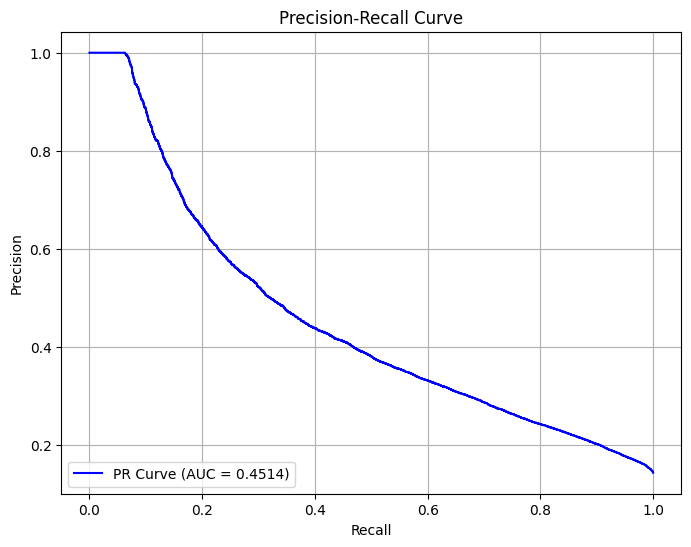

PR-AUC Score: 0.4513886335511099


In [44]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Calculate precision and recall values
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

# Calculate PR-AUC
pr_auc = auc(recall, precision)

# Plot PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='b', label=f'PR Curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

print("PR-AUC Score:", pr_auc)
